## Desafio 4 da Trilha de Visão Computacional

Nesse desafio você irá implementar uma solução simples para reconhecimento de poses, muito útil em análises esportivas por exemplo.

Para isso você deverá seguir os pasos desse documento atentamente.

### Instalação e Importação da Biblioteca

In [ ]:
!pip install ultralytics matplotlib torch tqdm

In [51]:
import ultralytics
import matplotlib.pyplot as plt
import torch

from pathlib import Path
from tqdm import tqdm

### Processar Dados



In [5]:
# Baixa o modelo de pose da YOLO.
model = ultralytics.YOLO("yolo11n-pose.pt")

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

# Processa a imagem.
# TODO testar outras imagens.
results = model("desafio_4.jpeg")  # predict on an image



image 1/1 /home/jr/Vídeos/computer-vision/desafios/desafio-04/VC_Desafio_4/desafio_4_pose_estimation/desafio_4.jpeg: 288x640 5 persons, 103.8ms
Speed: 5.2ms preprocess, 103.8ms inference, 8.3ms postprocess per image at shape (1, 3, 288, 640)


### Visualizar Resultados

In [7]:
print(results[0])

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: ultralytics.engine.results.Keypoints object
masks: None
names: {0: 'person'}
obb: None
orig_img: array([[[119, 140, 131],
        [118, 139, 130],
        [120, 139, 130],
        ...,
        [183, 220, 204],
        [194, 228, 211],
        [223, 246, 231]],

       [[120, 139, 130],
        [118, 137, 128],
        [118, 137, 128],
        ...,
        [200, 233, 219],
        [190, 226, 210],
        [199, 228, 212]],

       [[118, 137, 128],
        [117, 136, 127],
        [117, 136, 127],
        ...,
        [219, 247, 241],
        [204, 236, 225],
        [201, 227, 213]],

       ...,

       [[113, 134, 165],
        [113, 134, 162],
        [ 98, 115, 141],
        ...,
        [128, 121,  58],
        [128, 124,  59],
        [118, 115,  47]],

       [[107, 128, 159],
        [102, 123, 151],
        [ 98, 115, 141],
        ...,
        [116, 107,  44],

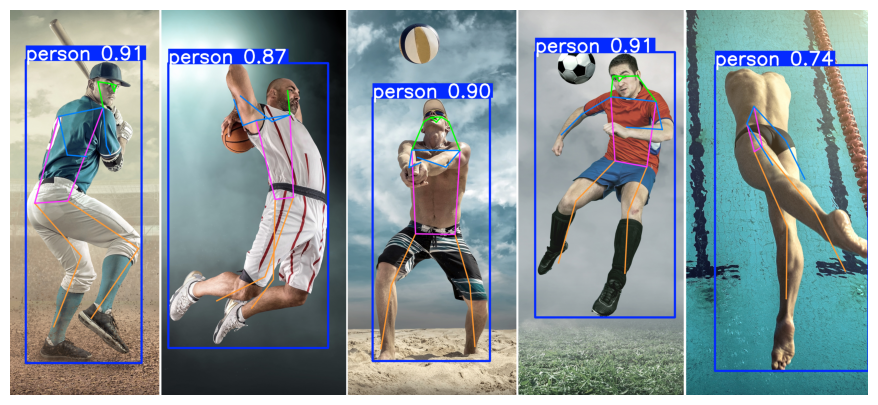

In [11]:
from PIL import Image
import cv2


# Gera visualização do resultado
im_array = results[0].plot()
rgb_img = cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB)


# Visualize a imagem rgb_img
plt.figure(figsize=(17, 5))
plt.imshow(rgb_img)
plt.axis("off")
plt.show()

### Usando em outras imagens 

**Djokovic (Goat) poses**

In [49]:
def plot_prediction(ax, result, title: str = "") -> None:
    im_array = result[0].plot()
    rgb_img = cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB)

    ax.imshow(rgb_img)
    ax.set_title(title)
    ax.axis("off")


def run_model(model, dir_name: str) -> None:
    directory = Path(dir_name)

    paths = sorted(list(directory.iterdir()))

    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    axes = axes.ravel()

    for idx, (ax, path) in tqdm(enumerate(zip(axes, paths)), desc="Realizando a predição da pose"):
        result = model(path, verbose=False)
        plot_prediction(ax, result, f'Djokovic pose {idx + 1}')

    plt.tight_layout()
    plt.show()

Realizando a predição da pose: 8it [00:01,  5.91it/s]


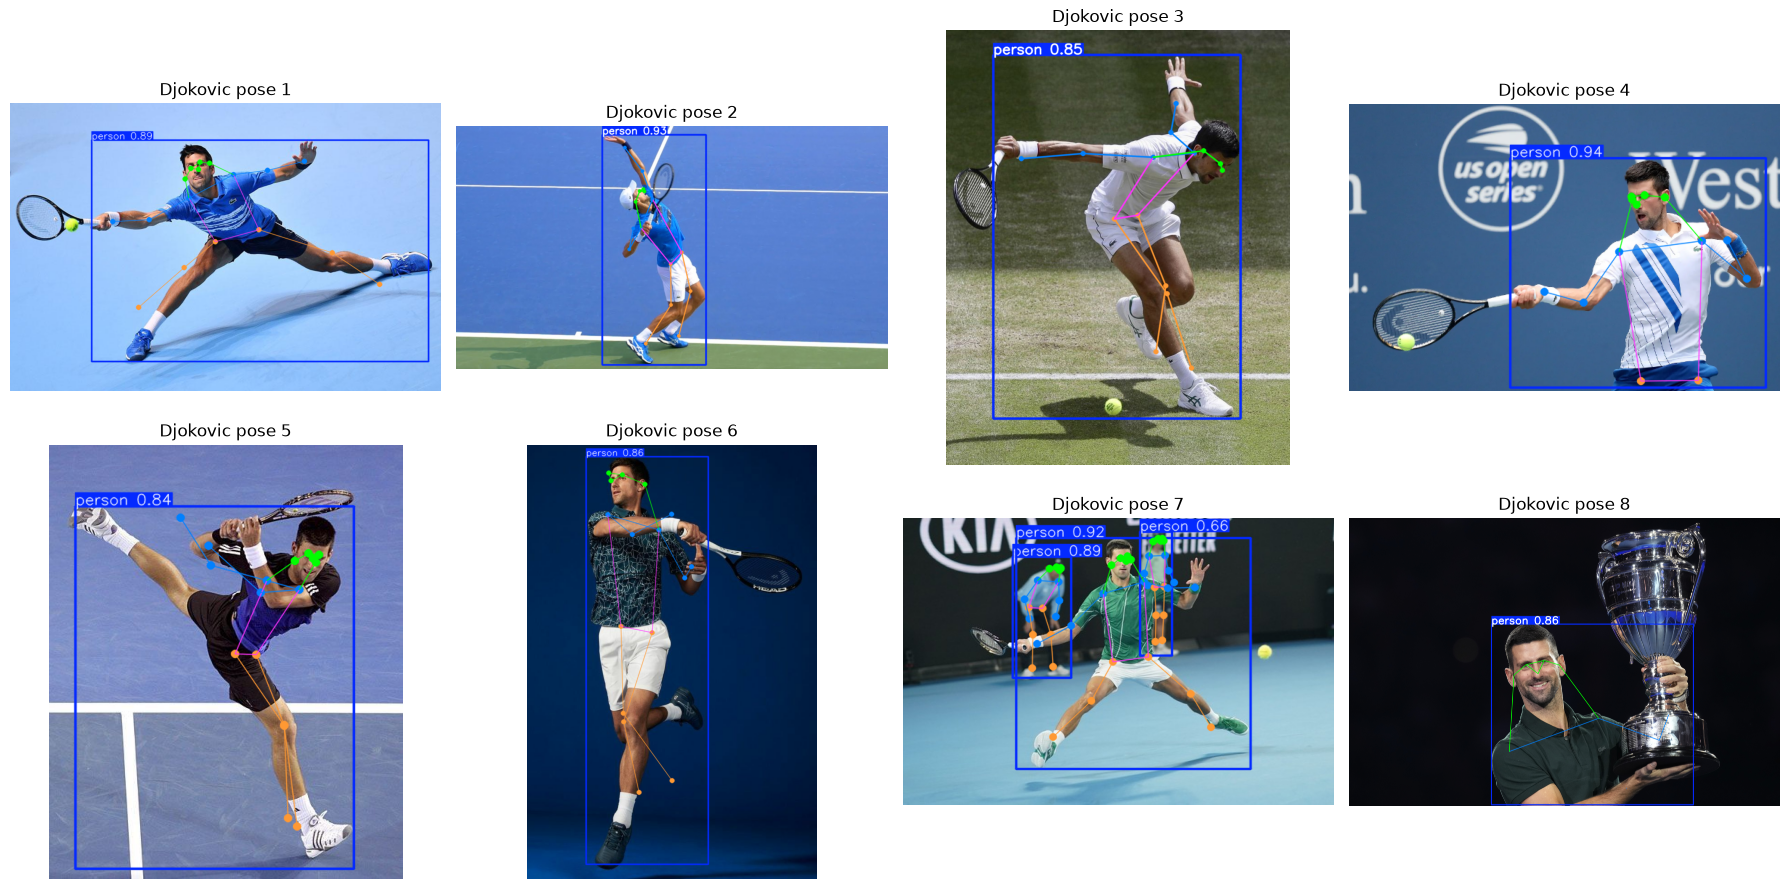

In [50]:
run_model(model, "djokovic")

### Referência

- https://docs.ultralytics.com/tasks/pose